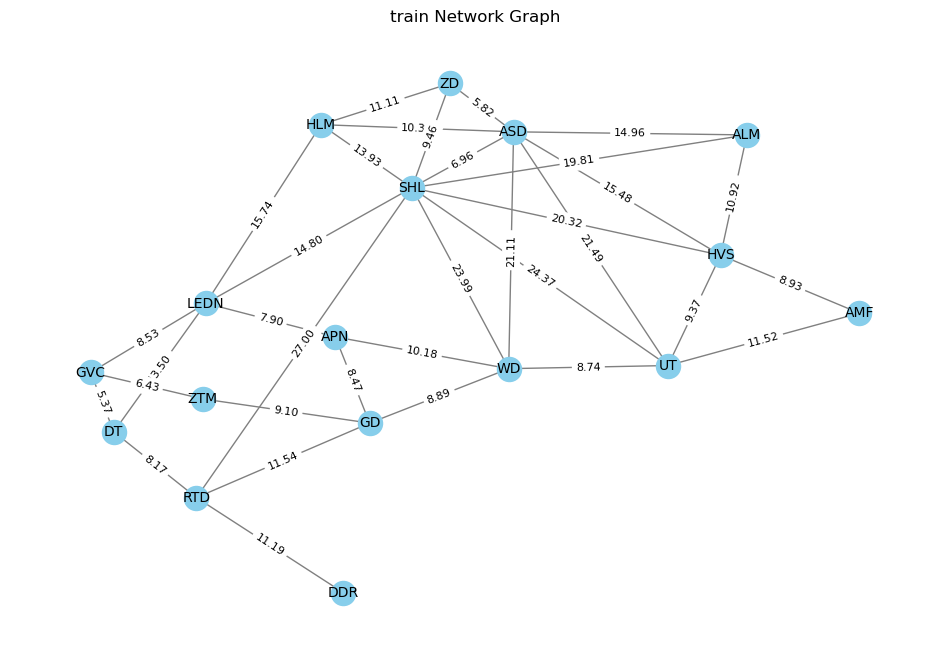

In [29]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

NETWORK_TYPE = "train"
# NETWORK_TYPE = "car"

# Load CSVs
nodes_df = pd.read_csv(f"network_nodes_{NETWORK_TYPE}.csv")  # columns: name, station, lat, lng
edges_df = pd.read_csv(f"network_edges_{NETWORK_TYPE}.csv")  # columns: from, to, travel_time

# Create undirected graph
G_red = nx.Graph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G_red.add_node(row['name'], lat=row['lat'], lon=row['lng'], station=row['station'])

# Add edges from CSV
for _, row in edges_df.iterrows():
    G_red.add_edge(row['from'], row['to'], weight=row['travel_time'])

# Positions based on lon/x and lat/y
pos = {node: (data['lon'], data['lat']) for node, data in G_red.nodes(data=True)}

# Plot the graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G_red, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(G_red, pos, edge_color='gray')  # undirected, no arrows
nx.draw_networkx_labels(G_red, pos, font_size=10, font_color='black')

# Edge labels = travel_time rounded to 2 decimals
edge_labels = { (u,v): f"{d['weight']:.2f}" for u,v,d in G_red.edges(data=True) }
nx.draw_networkx_edge_labels(G_red, pos, edge_labels=edge_labels, font_size=8)

plt.title(f"{NETWORK_TYPE} Network Graph")
plt.axis('off')
plt.show()

In [30]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [31]:
def calculate_travel_time(G, node1, node2, km_to_time=0.572):
    lat1 = G.nodes[node1]['lat']
    lon1 = G.nodes[node1]['lon']
    lat2 = G.nodes[node2]['lat']
    lon2 = G.nodes[node2]['lon']
    
    distance_km = haversine(lat1, lon1, lat2, lon2)
    travel_time = distance_km * km_to_time
    return travel_time

In [32]:
def evaluate_all_possible_new_edges(G, km_to_time=0.572):
    candidates = []

    for node1, node2 in combinations(G.nodes(), 2):
        # Skip if edge already exists
        if G.has_edge(node1, node2):
            continue

        # Estimate travel time for this new connection
        new_weight = calculate_travel_time(G, node1, node2, km_to_time=km_to_time)

        # Create modified graph with this single added edge
        G_modified = G.copy()
        G_modified.add_edge(node1, node2, weight=new_weight)

        candidates.append({
            "from_node": node1,
            "to_node": node2,
            "estimated_weight": new_weight,
            "G_modified": G_modified
        })

    return candidates

In [47]:
all_candidates = evaluate_all_possible_new_edges(G_red)

print(f"Number of possible new single-edge additions: {len(all_candidates)}")
print("Example candidate edges:")

# Example: inspect first few candidates
for c in all_candidates[:5]:
    print(c["from_node"], "->", c["to_node"], "| weight =", round(c["estimated_weight"], 2))

Number of possible new single-edge additions: 102
Example candidate edges:
ALM -> APN | weight = 27.01
ALM -> AMF | weight = 15.27
ALM -> DT | weight = 40.95
ALM -> GVC | weight = 39.51
ALM -> DDR | weight = 42.01


In [34]:
def plot_graph_with_highlight(G, new_edge, title="Graph"):
    pos = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

    plt.figure(figsize=(12, 8))

    # draw all edges
    nx.draw_networkx_edges(G, pos, edge_color='gray')

    # highlight new edge
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[new_edge],
        edge_color='red',
        width=2
    )

    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')
    nx.draw_networkx_labels(G, pos, font_size=10)

    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.show()

In [35]:
def evaluate_network_metrics(network):
    dcn = nx.degree_centrality(network)
    ccn = nx.closeness_centrality(network, distance='weight')
    bcn = nx.betweenness_centrality(network, weight='weight', normalized=True)
    lcn = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight')

    metrics_df = pd.DataFrame({
        'Node': list(network.nodes()),
        'Station': [network.nodes[n]['station'] for n in network.nodes()],
        'DCN':  [round(dcn[n],  4) for n in network.nodes()],
        'CCN':  [round(ccn[n],  4) for n in network.nodes()],
        'BCN':  [round(bcn[n],  4) for n in network.nodes()],
        'LCN':  [round(lcn[n],  4) for n in network.nodes()],
        'EC':   [round(eigenvector[n], 4) for n in network.nodes()],
    })

    metrics_df = metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)
    return metrics_df

In [41]:
hub_locations = ['SHL', 'UT', 'ASD']
metrics_original = evaluate_network_metrics(G_red)
metrics_original_hub = metrics_original[metrics_original['Node'].isin(hub_locations)]
print("Original Network Metrics:")
print(metrics_original_hub)


Original Network Metrics:
  Node             Station     DCN     CCN     BCN     LCN      EC
0  SHL    Schiphol Airport  0.5625  0.0440  0.1667  0.1543  0.5488
1  ASD  Amsterdam Centraal  0.4375  0.0417  0.0917  0.2229  0.3842
2   UT    Utrecht Centraal  0.3125  0.0416  0.1750  0.3319  0.3642


In [52]:
# Store best result per hub
best_links = {
    hub: {"score": float("-inf"), "candidate": None, "delta": None}
    for hub in hub_locations
}

In [53]:
for c in all_candidates:
    G_test = G_red.copy()
    G_test.add_edge(c["from_node"], c["to_node"], weight=c["estimated_weight"])

    metrics = evaluate_network_metrics(G_test)
    metrics_hub = metrics[metrics['Node'].isin(hub_locations)]

    delta_metrics = (
        metrics_hub.set_index('Node')[['DCN', 'CCN', 'BCN', 'LCN', 'EC']]
        - metrics_original_hub.set_index('Node')[['DCN', 'CCN', 'BCN', 'LCN', 'EC']]
    )

    # Evaluate each hub separately
    for hub in hub_locations:
        delta = delta_metrics.loc[hub]

        # Score = sum of improvements
        score = delta.sum()

        if score > best_links[hub]["score"]:
            best_links[hub] = {
                "score": score,
                "candidate": c,
                "delta": delta
            }

In [54]:
# Print results
for hub, result in best_links.items():
    print(f"\nBest link for {hub}:")
    print(result["candidate"])
    print("Score:", result["score"])
    print("Delta metrics:")
    print(result["delta"])


Best link for SHL:
{'from_node': 'DT', 'to_node': 'SHL', 'estimated_weight': np.float64(24.925351561461188), 'G_modified': <networkx.classes.graph.Graph object at 0x000001FB3AD2E250>}
Score: 0.09180000000000008
Delta metrics:
DCN    0.0625
CCN    0.0004
BCN    0.0083
LCN   -0.0022
EC     0.0228
Name: SHL, dtype: float64

Best link for UT:
{'from_node': 'ALM', 'to_node': 'UT', 'estimated_weight': np.float64(18.67386441511129), 'G_modified': <networkx.classes.graph.Graph object at 0x000001FB3A7C4B90>}
Score: 0.12319999999999999
Delta metrics:
DCN    0.0625
CCN    0.0001
BCN    0.0000
LCN    0.0163
EC     0.0443
Name: UT, dtype: float64

Best link for ASD:
{'from_node': 'AMF', 'to_node': 'ASD', 'estimated_weight': np.float64(23.235357430501136), 'G_modified': <networkx.classes.graph.Graph object at 0x000001FB3AD382D0>}
Score: 0.08830000000000005
Delta metrics:
DCN    0.0625
CCN    0.0002
BCN    0.0000
LCN   -0.0125
EC     0.0381
Name: ASD, dtype: float64
